<a href="https://colab.research.google.com/github/Annette-1/Ecuaciones_Diferenciales_Parciales/blob/main/Distribuci%C3%B3n_de_Poisson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style="color:purple;"> **Distribución de Poisson**</span>

<span style="color:teal;">**Nombre:**</span> Jerónimo López Annette Michelle

<span style="color:teal;">**Objetivo**</span> Generar variables discretas dada la función de Poisson.

###<span style="color:teal;">**Introducción a la distribución de Poisson**</span>

La distribución de Poisson es una distribución de probabilidad discreta que modela el número de veces que ocurre un evento en un intervalo fijo de tiempo, espacio, área, volumen o cualquier otra dimensión continua, bajo ciertas condiciones de aleatoriedad e independencia.

###<span style="color:teal;">**Interpretación conceptual**</span>

Su nombre proviene del matemático francés Siméon Denis Poisson (1781–1840), quien la introdujo en 1837. En esencia, responde preguntas como:

* ¿Cuántos clientes llegan a una tienda en una hora?

* ¿Cuántos accidentes ocurren en una carretera por semana?

* ¿Cuántas mutaciones aparecen en una secuencia de ADN de cierta longitud?

La variable aleatoria $X$ sigue una distribución de Poisson con parámetro
$λ$ (lambda), donde $λ$ representa la tasa media esperada de ocurrencias en el intervalo considerado.

Su función de probabilidad es:

$$
 P\{X=k\}= e^{-λ} \frac{λ^k}{k!},\quad k=0,1,2,...
$$

**Propiedades clave**:
- Media: $ E[X] = \lambda $
- Varianza: $ Var(X) = \lambda$
- Es asimétrica si $ \lambda$ es pequeño, y tiende a una distribución normal cuando $\lambda$ es grande.


###<span style="color:teal;">**Utilidad práctica**</span>

La distribución de Poisson es ampliamente usada en:

1. **Control de calidad y manufactura**: número de defectos por lote o por unidad de superficie.
2. **Telecomunicaciones**: número de llamadas que llegan a una central por minuto.
3. **Medicina y epidemiología**: número de casos raros de una enfermedad por año en una población.
4. **Tráfico y transporte**: número de vehículos que pasan por un peaje en un intervalo fijo.
5. **Biología y ecología**: conteo de individuos de una especie por cuadrante.
6. **Finanzas**: número de veces que un activo supera un umbral de precio en un día.

###<span style="color:teal;">**Relación con la distribución binomial**</pan>

La Poisson se puede obtener como **límite** de una distribución binomial $ B(n, p) $ cuando $ n $ es grande, $ p$ pequeño y $np = \lambda$ constante. Por eso es ideal para eventos raros en muchos ensayos (ley de eventos raros).

###<span style="color:teal;">**Condiciones de aplicación**</span>

Para que la Poisson sea adecuada, suelen cumplirse:
- Los eventos ocurren de forma independiente.
- La tasa media de ocurrencia es constante en el intervalo.
- Dos eventos no pueden ocurrir exactamente en el mismo instante (o punto espacial).



Graficamente:

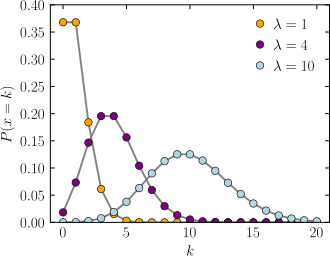

Función de distribución de probabilidad:

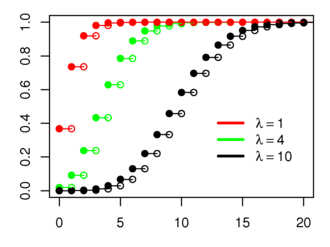

##  <span style="color:purple;"> **Genereación de una Variable Aleatoria Poisson**</span>

Una varibale $X$ es Poisson con media $λ$ si:

$$
p_i= P\{X=i\}= e^{-λ} \frac{λ^i}{i!},\quad i=0,1,2,...
$$

Para simular esta variable usaremos la identidad:
$$
P_{i+1=}\frac{λ}{i+1}p_i \quad ; i \geq0
$$

Para aplicar el Método de la Transformada Inversa.

---
*Seudocódigo*

1.- Generar $R∼U(0,1)$

2.- $i=0$ , $p=e^{-λ}$ ,$F=p$

3.- Si $U<F$: Hacer $x_i$ y terminar

4.- $P=\frac{λp}{i+1}$ ,$F=F+p$, $i=i+1$

5.- Ir al paso 3.-

---

In [40]:
#Importamos librerias
import numpy as np
import random as r
import matplotlib.pyplot as plt
import math #Libreria para realizar cálculos matemáticos avanzados sin tener que escribir funciones complejas.

Del seudocódigo tenemos:

In [41]:
def generar_poisson(n, lamda):
    """
    Genera n valores aleatorios de una distribución Poisson(lambda)
    usando el algoritmo de la transformada inversa
    """
    L = [] #Lista vacia para guardar los valores de x

    for _ in range(n):
        # Paso 1: Generar R ~ U(0,1)
        R = r.random()

        # Paso 2: Inicializar
        i = 0
        p = np.exp(-lamda)  # probabilidad en i=0
        F = p               # probabilidad acumulada hasta i=0

        # Paso 3: Verificar si R es menor que la probabilidad acumulada
        while R >= F:       # mientras R no sea menor que F
            # Paso 4: Actualizar para el siguiente valor
            p = (lamda * p) / (i + 1)  # P(X = i+1)
            i = i + 1
            F = F + p                   # Actualizar acumulada

        # Paso 5: Cuando R < F, hemos encontrado el valor
        X = i
        L.append(X)

    return L

In [42]:
# Generar 1000 valores con lambda = 4 (por ejemplo)
M = generar_poisson(1000, lamda=4)

Agrgamos la función de probabilidad de Poisson Teórica:

$$
 P\{X=k\}= e^{-λ} \frac{λ^k}{k!},\quad k=0,1,2,...
$$

Para comparar con la simulación

In [43]:
# Función de probabilidad teórica de Poisson
def poisson_pmf(k, lamda):
    """Calcula P(X=k) para Poisson(lambda)"""
    return (np.exp(-lamda) * (lamda ** k)) / math.factorial(k)
#definimos el valor de lamda
lamda = 4

In [44]:
# Agregar la función teórica de Poisson
x_teorico = np.arange(0, max(M)+1)  # valores desde 0 hasta el máximo
y_teorico = [poisson_pmf(k, lamda) for k in x_teorico]

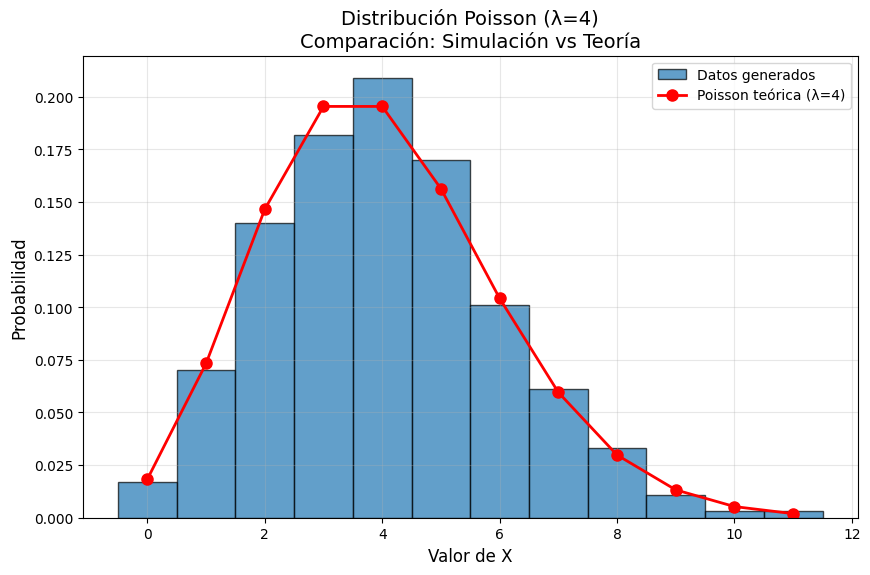

In [45]:
# Crear la gráfica
plt.figure(figsize=(10, 6))

# Histograma de los datos generados
counts, bins, patches = plt.hist(M, bins=np.arange(-0.5, max(M)+1.5, 1),
                                  density=True, alpha=0.7, edgecolor='black',
                                  label='Datos generados')
# Graficar la función teórica
plt.plot(x_teorico, y_teorico, 'ro-', linewidth=2, markersize=8,
         label=f'Poisson teórica (λ={lamda})')

# Decoración
plt.xlabel('Valor de X', fontsize=12)
plt.ylabel('Probabilidad', fontsize=12)
plt.title(f'Distribución Poisson (λ={lamda})\nComparación: Simulación vs Teoría', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### <span style="color:teal;">**Conclusión:**</span>

Se implementó el algoritmo de transformada inversa para simular la distribución de Poisson. Los resultados obtenidos para diferentes valores de $λ$ confirman las propiedades teóricas de la distribución: media igual a varianza igual a $λ$, y la transición desde una forma asimétrica hacia una forma aproximadamente normal a medida que $λ$ aumenta. La comparación entre el histograma de los datos simulados y la función de probabilidad teórica muestra una excelente aproximación, validando tanto el método de simulación como la comprensión conceptual de la distribución.

Ádemas la distribución de Poisson es una herramienta fundamental para modelar conteos aleatorios cuando se conoce la frecuencia media pero no se sabe exactamente cuándo ocurrirá cada evento. Su simplicidad matemática y su gran aplicabilidad la convierten en un pilar de la estadística y la ciencia de datos.